<a href="https://www.kaggle.com/code/ashikuzzamanshishir/test-module?scriptVersionId=274057982" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# ==========================================================
# 🦴 Bone Fracture Detection — Kaggle Free Environment
# End-to-end pipeline with toggles for full requirements
# ==========================================================

import os, sys, shutil, random, glob, time, json, gc, math
from collections import defaultdict
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cv2
from tqdm import tqdm

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim
from statsmodels.stats.contingency_tables import mcnemar

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger

# (Optional) transformers — enabled only when FAST_MODE=False
try:
    import torch, timm
    from torch import nn
    from torch.utils.data import Dataset, DataLoader
    from torchvision import transforms
    TORCH_OK = True
except Exception:
    TORCH_OK = False

print("TensorFlow:", tf.__version__)
print("PyTorch ok:", TORCH_OK)


2025-11-06 19:36:06.722421: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762457766.910376      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762457766.960384      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `ty

TensorFlow: 2.18.0
PyTorch ok: True


In [2]:
# ================== PATHS ==================
DATA_DIR = "/kaggle/input/bone-fracture-dataset/Bone fracture dataset/Bone fracture dataset/Dataset"
WORK_DIR = "/kaggle/working/bone_fracture_work"
SPLIT_ROOT = os.path.join(WORK_DIR, "splits")
TRAIN_DIR = os.path.join(SPLIT_ROOT, "train")
VAL_DIR   = os.path.join(SPLIT_ROOT, "val")
TEST_DIR  = os.path.join(SPLIT_ROOT, "test")
AUG_TRAIN_DIR = os.path.join(SPLIT_ROOT, "train_aug2")
MIXT_DIR  = os.path.join(SPLIT_ROOT, "mixt")

os.makedirs(WORK_DIR, exist_ok=True)

# ================== DATA/IMG ==================
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 10              # fast run
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# ================== MIXT ==================
MIXT_TOTAL = 20
MIXT_PER_CLASS = MIXT_TOTAL // 2

# ================== TOGGLES ==================
FAST_MODE = True   # <<< Set to False to run the FULL requirement suite (slow on free Kaggle)

# When FAST_MODE is False:
FULL_EPOCHS = 40
RUN_CNN_MODELS = not FAST_MODE
RUN_ATTENTION  = not FAST_MODE
RUN_TRANSFORMERS = (not FAST_MODE) and TORCH_OK
RUN_ENSEMBLE  = not FAST_MODE
RUN_FIVE_FOLD = not FAST_MODE
RUN_OPTUNA    = False  # Optional; off by default

print("FAST_MODE:", FAST_MODE)
print("WORK_DIR:", WORK_DIR)


FAST_MODE: True
WORK_DIR: /kaggle/working/bone_fracture_work


In [3]:
IMG_EXT = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")
classes = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
classes = sorted(classes)
assert len(classes) == 2, f"Expected 2 classes; found {classes}"
print("Detected classes:", classes)

all_paths = {c: sorted([p for p in glob.glob(os.path.join(DATA_DIR, c, "**"), recursive=True)
                        if os.path.isfile(p) and p.lower().endswith(IMG_EXT)])
             for c in classes}
counts = {c: len(all_paths[c]) for c in classes}
print("Image counts:", counts, "| Total:", sum(counts.values()))


Detected classes: ['fracture', 'normal']
Image counts: {'fracture': 2000, 'normal': 127} | Total: 2127


In [4]:
if os.path.exists(SPLIT_ROOT):
    shutil.rmtree(SPLIT_ROOT)

for root in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    for c in classes:
        os.makedirs(os.path.join(root, c), exist_ok=True)

for c in classes:
    paths = all_paths[c]
    temp, test_c = train_test_split(paths, test_size=TEST_SPLIT, random_state=SEED, shuffle=True)
    rel_val = VAL_SPLIT / (1.0 - TEST_SPLIT)
    train_c, val_c = train_test_split(temp, test_size=rel_val, random_state=SEED, shuffle=True)
    for src in train_c:
        shutil.copy2(src, os.path.join(TRAIN_DIR, c, os.path.basename(src)))
    for src in val_c:
        shutil.copy2(src, os.path.join(VAL_DIR, c, os.path.basename(src)))
    for src in test_c:
        shutil.copy2(src, os.path.join(TEST_DIR, c, os.path.basename(src)))

def count_dir(root):
    return {c: len(glob.glob(os.path.join(root, c, "*"))) for c in classes}

print("Split counts:")
print("Train:", count_dir(TRAIN_DIR))
print("Val  :", count_dir(VAL_DIR))
print("Test :", count_dir(TEST_DIR))


Split counts:
Train: {'fracture': 1400, 'normal': 88}
Val  : {'fracture': 300, 'normal': 19}
Test : {'fracture': 300, 'normal': 20}


In [5]:
def preprocess_image_np(img_rgb_uint8):
    lab = cv2.cvtColor(img_rgb_uint8, cv2.COLOR_RGB2LAB)
    L, A, B = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    L2 = clahe.apply(L)
    lab2 = cv2.merge([L2, A, B])
    rgb2 = cv2.cvtColor(lab2, cv2.COLOR_LAB2RGB)
    rgb2 = cv2.GaussianBlur(rgb2, (3,3), 0)   # optional denoise
    rgb2 = rgb2.astype(np.float32) / 255.0
    return rgb2

def preprocessing_function(img):
    img = np.clip(img, 0, 255).astype(np.uint8)
    return preprocess_image_np(img)

def load_resize_rgb(path, size=IMG_SIZE):
    x = cv2.imread(path, cv2.IMREAD_COLOR)
    x = cv2.cvtColor(x, cv2.COLOR_BGR2RGB)
    x = cv2.resize(x, size, interpolation=cv2.INTER_AREA)
    return x


In [6]:
sample_files = []
for c in classes:
    pool = glob.glob(os.path.join(TRAIN_DIR, c, "*"))
    sample_files += random.sample(pool, min(8, len(pool)))

psnr_vals, ssim_vals = [], []
for p in sample_files:
    raw = load_resize_rgb(p)
    proc = (preprocess_image_np(raw) * 255.0).astype(np.uint8)
    psnr_vals.append(psnr(raw, proc, data_range=255))
    ssim_vals.append(ssim(raw, proc, channel_axis=2, data_range=255))

print(f"Sample size: {len(sample_files)} | Avg PSNR: {np.mean(psnr_vals):.3f} dB | Avg SSIM: {np.mean(ssim_vals):.4f}")


Sample size: 16 | Avg PSNR: 25.196 dB | Avg SSIM: 0.8999


In [7]:
if os.path.exists(AUG_TRAIN_DIR):
    shutil.rmtree(AUG_TRAIN_DIR)
for c in classes:
    os.makedirs(os.path.join(AUG_TRAIN_DIR, c), exist_ok=True)

aug_gen_1 = ImageDataGenerator(
    preprocessing_function=preprocessing_function,
    rotation_range=12, width_shift_range=0.08, height_shift_range=0.08,
    zoom_range=0.12, horizontal_flip=True, fill_mode="nearest"
)
aug_gen_2 = ImageDataGenerator(
    preprocessing_function=preprocessing_function,
    rotation_range=8, width_shift_range=0.06, height_shift_range=0.06,
    zoom_range=0.10, horizontal_flip=True, shear_range=6, fill_mode="nearest"
)

def save_aug_versions(input_dir, out_dir, versions=2):
    for c in classes:
        cur = glob.glob(os.path.join(input_dir, c, "*"))
        for src in tqdm(cur, desc=f"Aug {c}"):
            base = os.path.splitext(os.path.basename(src))[0]
            img = load_resize_rgb(src, IMG_SIZE)
            for k in range(versions):
                gen = aug_gen_1 if k == 0 else aug_gen_2
                x = tf.keras.preprocessing.image.img_to_array(img).astype(np.float32)
                x = np.expand_dims(x, 0)
                aug_iter = gen.flow(x, batch_size=1, shuffle=False)
                aug = next(aug_iter)[0]     # already preprocessed to [0,1]
                out = (aug * 255).astype(np.uint8)
                out_path = os.path.join(out_dir, c, f"{base}_aug{k+1}.jpg")
                cv2.imwrite(out_path, cv2.cvtColor(out, cv2.COLOR_RGB2BGR))

save_aug_versions(TRAIN_DIR, AUG_TRAIN_DIR, versions=2)
print("Aug counts:", count_dir(AUG_TRAIN_DIR))


Aug normal: 100%|██████████| 88/88 [00:07<00:00, 12.19it/s]

Aug counts: {'fracture': 2800, 'normal': 176}


In [8]:
train_gen = ImageDataGenerator(preprocessing_function=preprocessing_function)
val_test_gen = ImageDataGenerator(preprocessing_function=preprocessing_function)

train_flow = train_gen.flow_from_directory(AUG_TRAIN_DIR, target_size=IMG_SIZE,
                                           batch_size=BATCH_SIZE, class_mode="binary", shuffle=True, seed=SEED)
val_flow = val_test_gen.flow_from_directory(VAL_DIR, target_size=IMG_SIZE,
                                           batch_size=BATCH_SIZE, class_mode="binary", shuffle=False)
test_flow = val_test_gen.flow_from_directory(TEST_DIR, target_size=IMG_SIZE,
                                            batch_size=BATCH_SIZE, class_mode="binary", shuffle=False)

idx_to_class = {v:k for k,v in train_flow.class_indices.items()}
classes_ordered = [k for k,_ in sorted(train_flow.class_indices.items(), key=lambda x:x[1])]
print("Class indices:", train_flow.class_indices)


Found 2976 images belonging to 2 classes.
Found 319 images belonging to 2 classes.
Found 320 images belonging to 2 classes.
Class indices: {'fracture': 0, 'normal': 1}


In [9]:
def binary_metrics(y_true, y_pred, y_prob=None):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    acc = (tp+tn)/cm.sum()
    ppv = tp/(tp+fp+1e-9)         # precision
    npv = tn/(tn+fn+1e-9)
    sens = tp/(tp+fn+1e-9)        # recall
    spec = tn/(tn+fp+1e-9)
    f1 = 2*ppv*sens/(ppv+sens+1e-9)
    return {"accuracy":acc, "precision":ppv, "recall":sens, "specificity":spec, "npv":npv, "f1":f1, "cm":cm}

def bootstrap_accuracy(y_true, y_pred, n=1000, seed=SEED):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(y_true))
    accs = [accuracy_score(y_true[rng.choice(idx, size=len(idx), replace=True)],
                           y_pred[rng.choice(idx, size=len(idx), replace=True)]) for _ in range(n)]
    lo, hi = np.percentile(accs, [2.5, 97.5])
    return {"mean": float(np.mean(accs)), "ci95": (float(lo), float(hi))}

class Timer:
    def __enter__(self): self.t0=time.time(); return self
    def __exit__(self,*exc): self.elapsed=time.time()-self.t0


In [10]:
from tensorflow.keras.applications import EfficientNetB0

L2 = 1e-4
DROP = 0.5

def build_efficientnet():
    base = EfficientNetB0(include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), weights="imagenet")
    base.trainable = False
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(DROP)(x)
    out = layers.Dense(1, activation="sigmoid", kernel_regularizer=regularizers.l2(L2))(x)
    m = models.Model(base.input, out, name="EfficientNetB0_bin")
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])
    return m, base

E = FULL_EPOCHS if not FAST_MODE else EPOCHS
m, base = build_efficientnet()
callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=5 if not FAST_MODE else 3, restore_best_weights=True, verbose=1),
    ModelCheckpoint(os.path.join(WORK_DIR,"best_effb0.h5"), monitor="val_accuracy", save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
]
with Timer() as ttrain:
    hist = m.fit(train_flow, validation_data=val_flow, epochs=E, verbose=1)

print(f"Train time (s): {ttrain.elapsed:.1f}")


I0000 00:00:1762457855.976974      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1762457855.977680      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1762457873.782573      90 service.cc:148] XLA service 0x7ae31000bc70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762457873.783485      90 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1762457873.783514      90 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1762457875.621692      90 cuda_dnn.cc:529] Loaded cuDNN version 90300


  4/186 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.4219 - loss: 0.7195

I0000 00:00:1762457884.452977      90 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


186/186 ━━━━━━━━━━━━━━━━━━━━ 51s 137ms/step - accuracy: 0.8997 - loss: 0.2999 - val_accuracy: 0.9404 - val_loss: 0.2266
Epoch 2/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - accuracy: 0.9377 - loss: 0.2369 - val_accuracy: 0.9404 - val_loss: 0.2307
Epoch 3/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 76ms/step - accuracy: 0.9420 - loss: 0.2265 - val_accuracy: 0.9404 - val_loss: 0.2312
Epoch 4/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - accuracy: 0.9403 - loss: 0.2344 - val_accuracy: 0.9404 - val_loss: 0.2270
Epoch 5/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 76ms/step - accuracy: 0.9359 - loss: 0.2454 - val_accuracy: 0.9404 - val_loss: 0.2262
Epoch 6/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - accuracy: 0.9407 - loss: 0.2301 - val_accuracy: 0.9404 - val_loss: 0.2270
Epoch 7/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - accuracy: 0.9442 - loss: 0.2221 - val_accuracy: 0.9404 - val_loss: 0.2270
Epoch 8/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 15s 78ms/step - accuracy: 0.9387 - loss: 0.2342 - val_accura

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classif

== Train ==
              precision    recall  f1-score   support

    fracture       0.94      1.00      0.97      2800
      normal       0.00      0.00      0.00       176

    accuracy                           0.94      2976
   macro avg       0.47      0.50      0.48      2976
weighted avg       0.89      0.94      0.91      2976

== Val ==
              precision    recall  f1-score   support

    fracture       0.94      1.00      0.97       300
      normal       0.00      0.00      0.00        19

    accuracy                           0.94       319
   macro avg       0.47      0.50      0.48       319
weighted avg       0.88      0.94      0.91       319

== Test ==
              precision    recall  f1-score   support

    fracture       0.94      1.00      0.97       300
      normal       0.00      0.00      0.00        20

    accuracy                           0.94       320
   macro avg       0.47      0.50      0.48       320
weighted avg       0.88      0.94      0.

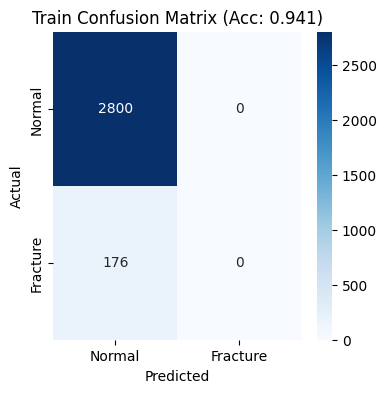

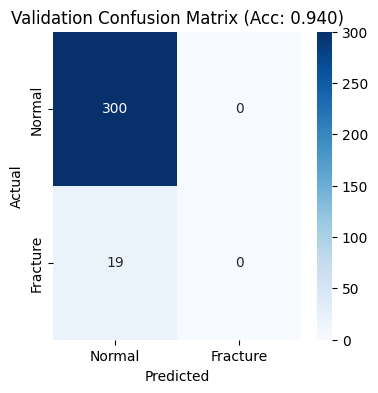

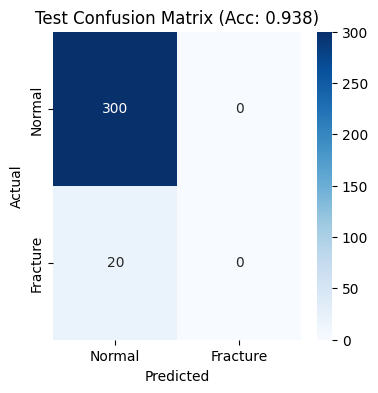

In [11]:
# ==========================================================
# ✅ Evaluation with Confusion Matrices (Train / Val / Test)
# ==========================================================
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def eval_gen(model, gen):
    """Evaluate model on a generator and compute metrics."""
    loss, acc = model.evaluate(gen, verbose=0)
    prob = model.predict(gen, verbose=0).ravel()
    pred = (prob >= 0.5).astype(int)
    y = gen.classes
    met = binary_metrics(y, pred, prob)
    rep = classification_report(y, pred, target_names=classes_ordered)
    boot = bootstrap_accuracy(y, pred, 1000 if not FAST_MODE else 200)
    return {"loss":loss,"acc":acc,"metrics":met,"report":rep,"boot_acc":boot, "y":y, "pred":pred}

# Run evaluations
train_eval = eval_gen(m, train_flow)
val_eval   = eval_gen(m, val_flow)
test_eval  = eval_gen(m, test_flow)

# Print reports
print("== Train ==")
print(train_eval["report"])
print("== Val ==")
print(val_eval["report"])
print("== Test ==")
print(test_eval["report"])
print("Bootstrap Acc (test):", test_eval["boot_acc"])

# ==========================================================
# 🔹 Confusion Matrices for each split
# ==========================================================
splits = {
    "Train": train_eval,
    "Validation": val_eval,
    "Test": test_eval
}

for name, result in splits.items():
    y_true = result["y"]
    y_pred = result["pred"]
    cm = confusion_matrix(y_true, y_pred)
    acc = result["acc"]
    
    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "Fracture"],
                yticklabels=["Normal", "Fracture"])
    plt.title(f"{name} Confusion Matrix (Acc: {acc:.3f})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


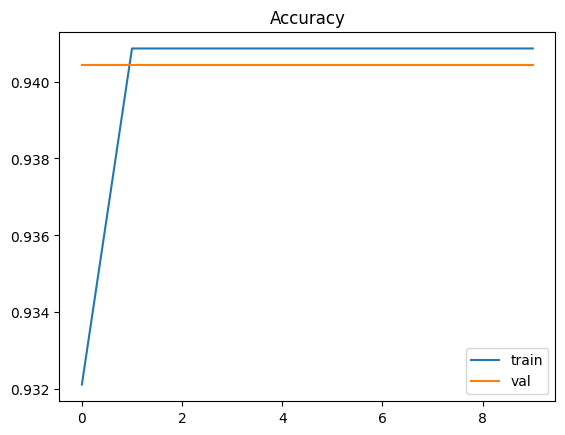

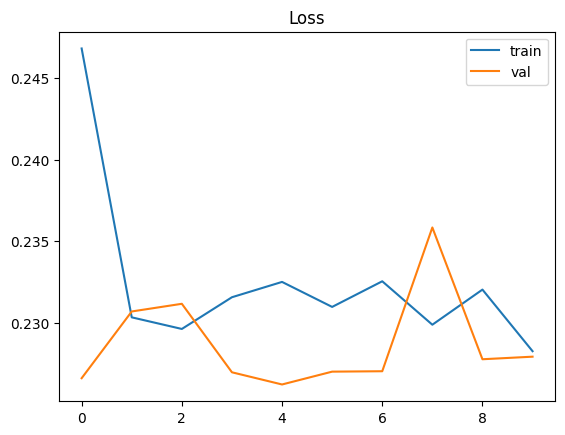

In [12]:
plt.figure(); plt.plot(hist.history["accuracy"], label="train"); plt.plot(hist.history.get("val_accuracy",[]), label="val")
plt.title("Accuracy"); plt.legend(); plt.show()
plt.figure(); plt.plot(hist.history["loss"], label="train"); plt.plot(hist.history.get("val_loss",[]), label="val")
plt.title("Loss"); plt.legend(); plt.show()


✅ Using main dataset folder: /kaggle/input/bone-fracture-dataset/Bone fracture dataset/Bone fracture dataset/Dataset
📸 Found 2127 total images (fracture + normal)
✅ Using device: /GPU:0
🎯 Running Grad-CAM on 5 random images from main dataset...

🩻 [1] 673.png


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


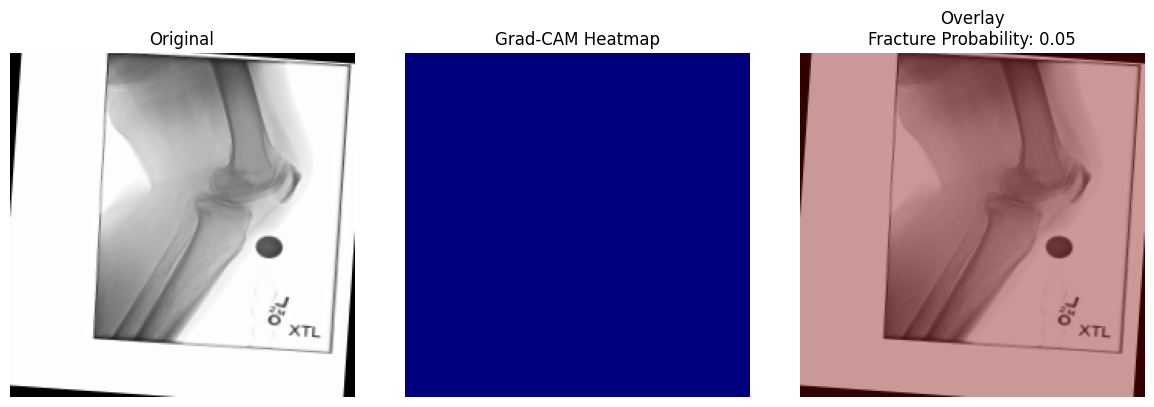


🩻 [2] 1839.png


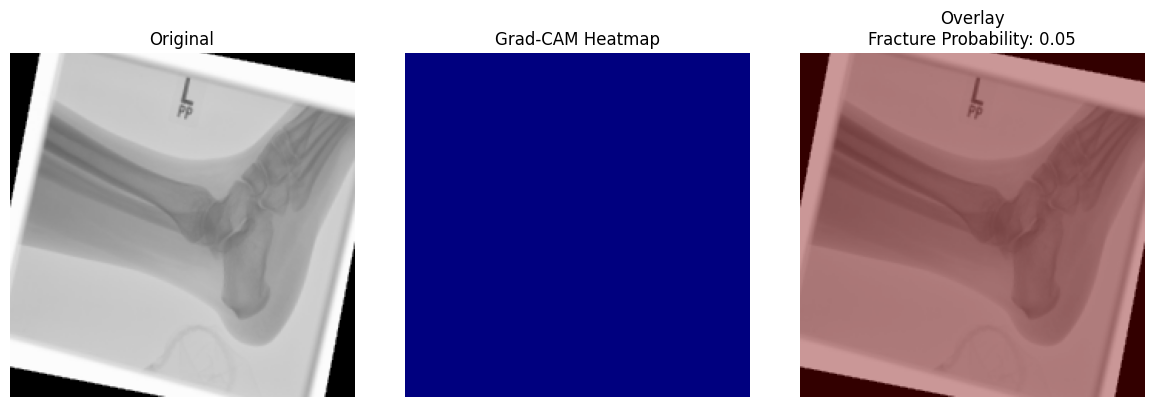


🩻 [3] 112.png


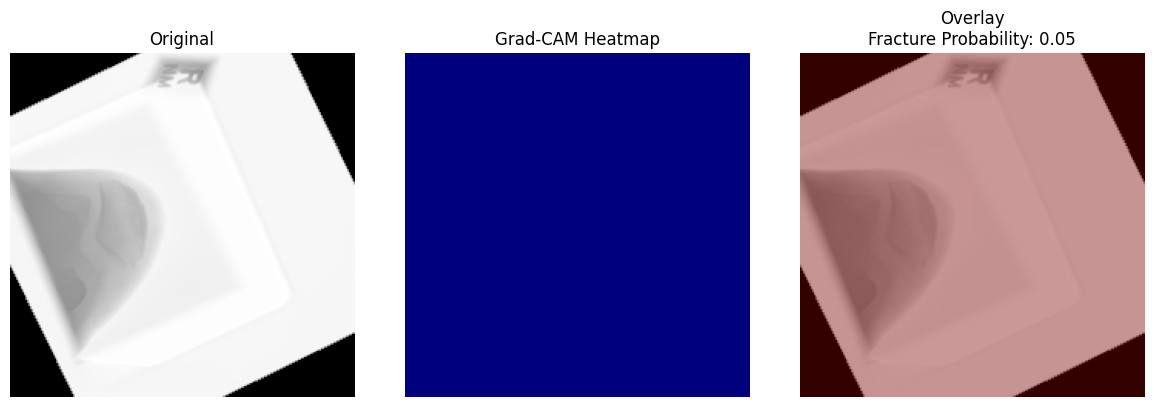


🩻 [4] 1334.png


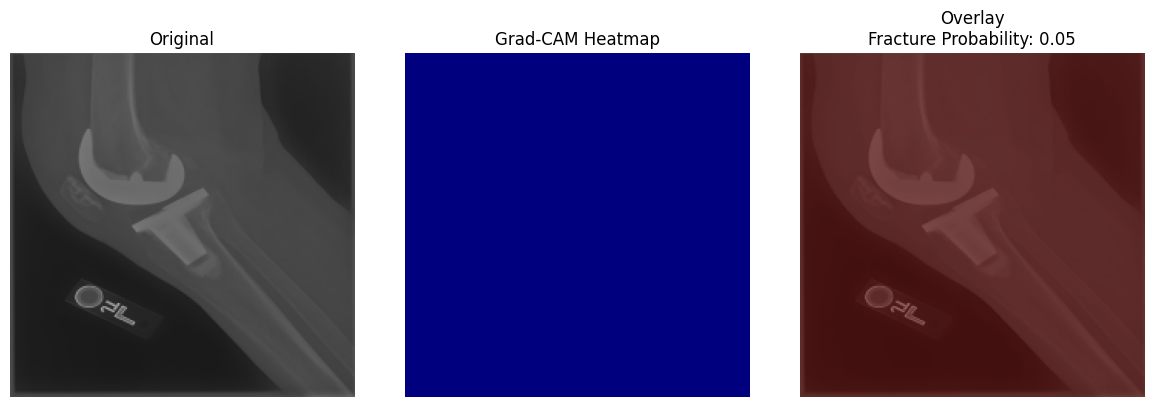


🩻 [5] 671.png


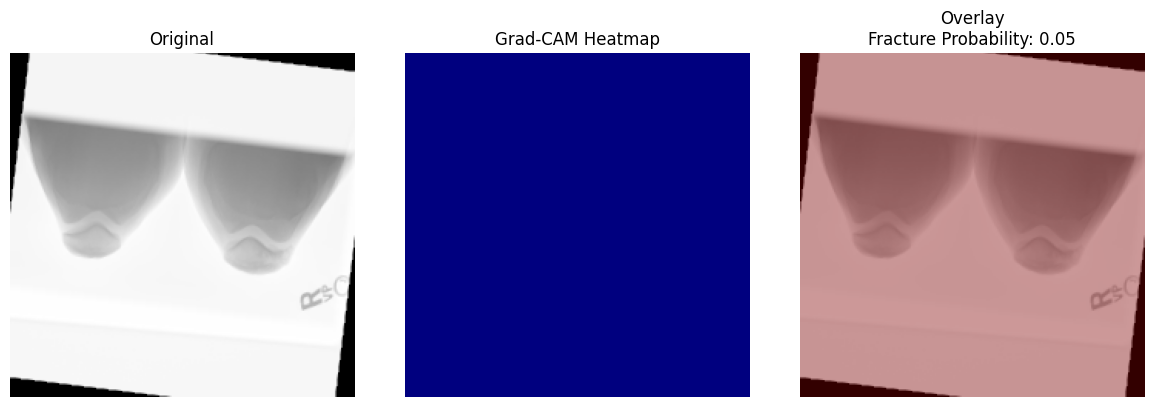

In [13]:
# ==========================================================
# ✅ FINAL FIXED: Grad-CAM Visualization (Main Dataset Folder Only)
# ==========================================================
import os, glob, random, cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ------------------ STEP 1: Detect main dataset folder ------------------
root_candidates = [
    "/kaggle/input/bone-fracture-dataset/",
    "/kaggle/input/bone-fracture-dataset-only/",
    "/kaggle/input/"
]

SOURCE_MAIN = None
for root in root_candidates:
    for subdir, dirs, files in os.walk(root):
        if "fracture" in dirs and "normal" in dirs:
            SOURCE_MAIN = subdir
            break
    if SOURCE_MAIN:
        break

if not SOURCE_MAIN:
    raise FileNotFoundError("❌ Could not locate main dataset folder containing 'fracture' and 'normal'!")

print(f"✅ Using main dataset folder: {SOURCE_MAIN}")

# ------------------ STEP 2: Gather all images from main dataset ------------------
all_imgs = glob.glob(os.path.join(SOURCE_MAIN, "fracture", "*.*")) + \
           glob.glob(os.path.join(SOURCE_MAIN, "normal", "*.*"))
all_imgs = [f for f in all_imgs if f.lower().endswith(("jpg", "jpeg", "png"))]

if not all_imgs:
    raise RuntimeError("❌ No images found inside main dataset folder!")

print(f"📸 Found {len(all_imgs)} total images (fracture + normal)")

# ------------------ STEP 3: Pick trained model ------------------
if "m" in globals():
    model_to_use = m
elif "models_list" in globals() and len(models_list) > 0:
    model_to_use = models_list[0]
else:
    raise RuntimeError("❌ No trained model found! Please train or load a model first.")

device_name = "/GPU:0" if tf.config.list_physical_devices('GPU') else "/CPU:0"
print(f"✅ Using device: {device_name}")

# ------------------ STEP 4: Grad-CAM helper functions ------------------
def load_rgb(img_path, size=(224, 224)):
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"❌ Cannot read: {img_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)
    return img

def grad_cam(model, img_path, size=(224, 224)):
    raw = load_rgb(img_path, size)
    x = np.expand_dims(raw.astype(np.float32) / 255.0, axis=0)

    # Find last conv layer
    last_conv = None
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv = layer.name
            break
    if last_conv is None:
        raise ValueError("❌ No Conv2D layer found in model.")

    grad_model = tf.keras.models.Model([model.inputs],
                                       [model.get_layer(last_conv).output, model.output])

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(x)
        class_channel = preds[:, 0]

    grads = tape.gradient(class_channel, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2)).numpy()
    conv_output = conv_out[0].numpy()

    for i in range(pooled_grads.shape[-1]):
        conv_output[:, :, i] *= pooled_grads[i]

    heatmap = np.mean(conv_output, axis=-1)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= (np.max(heatmap) + 1e-8)
    heatmap = cv2.resize(heatmap, (raw.shape[1], raw.shape[0]))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(raw, 0.6, heatmap_color, 0.4, 0)

    return raw, heatmap, overlay, float(preds.numpy()[0][0])

# ------------------ STEP 5: Run Grad-CAM on multiple samples ------------------
num_samples = 5
chosen_imgs = random.sample(all_imgs, min(num_samples, len(all_imgs)))
print(f"🎯 Running Grad-CAM on {len(chosen_imgs)} random images from main dataset...")

for i, img_path in enumerate(chosen_imgs, 1):
    print(f"\n🩻 [{i}] {os.path.basename(img_path)}")
    raw, hm, ov, prob = grad_cam(model_to_use, img_path)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1); plt.imshow(raw); plt.title("Original"); plt.axis("off")
    plt.subplot(1, 3, 2); plt.imshow(hm, cmap="jet"); plt.title("Grad-CAM Heatmap"); plt.axis("off")
    plt.subplot(1, 3, 3); plt.imshow(ov); plt.title(f"Overlay\nFracture Probability: {prob:.2f}"); plt.axis("off")
    plt.tight_layout()
    plt.show()


✅ Using GPU for training: /physical_device:GPU:0
🔹 Starting CNN training & evaluation for all backbones...

==================== ResNet50 ====================
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

🚀 Training ResNet50 for 5 epochs...
Epoch 1/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9030 - loss: 0.3032
Epoch 1: val_accuracy improved from -inf to 0.94044, saving model to /kaggle/working/bone_fracture_work/ResNet50_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 37s 122ms/step - accuracy: 0.9032 - loss: 0.3029 - val_accuracy: 0.9404 - val_loss: 0.2271 - learning_rate: 0.0010
Epoch 2/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9424 - loss: 0.2254
Epoch 2: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 15s 78ms/step - accuracy: 0.9424 - loss: 0.2254 - val_accuracy: 0.9404 - val_loss: 0.2306 - learning_rate: 0.0010
Epoch 3/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9379 - loss: 0.2414
Epoch 3: val_accuracy did not improv

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


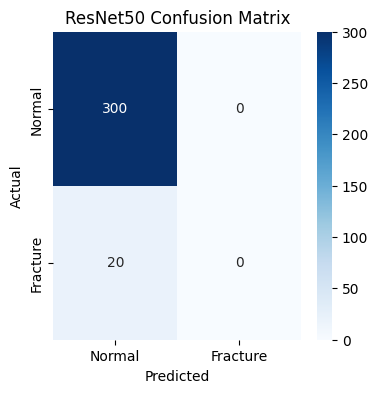

==================== VGG16 ====================
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

🚀 Training VGG16 for 5 epochs...
Epoch 1/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.8833 - loss: 0.3517
Epoch 1: val_accuracy improved from -inf to 0.94044, saving model to /kaggle/working/bone_fracture_work/VGG16_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 42s 171ms/step - accuracy: 0.8835 - loss: 0.3513 - val_accuracy: 0.9404 - val_loss: 0.2193 - learning_rate: 0.0010
Epoch 2/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.9381 - loss: 0.2323
Epoch 2: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 23s 122ms/step - accuracy: 0.9381 - loss: 0.2323 - val_accuracy: 0.9404 - val_loss: 0.2174 - learning_rate: 0.0010
Epoch 3/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9459 - loss: 0.2047
Epoch 3: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 22s 119ms/step - accuracy: 0.9458 - loss: 0.2048 - val_accuracy: 0.94

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Classification report:
               precision    recall  f1-score   support

    fracture       0.94      1.00      0.97       300
      normal       0.00      0.00      0.00        20

    accuracy                           0.94       320
   macro avg       0.47      0.50      0.48       320
weighted avg       0.88      0.94      0.91       320



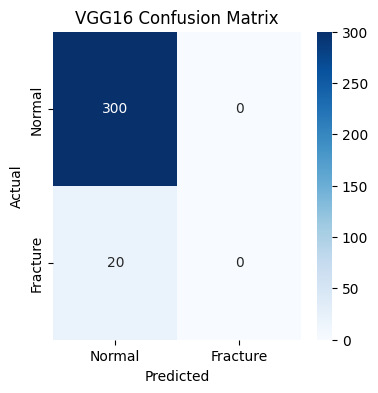

==================== InceptionV3 ====================
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

🚀 Training InceptionV3 for 5 epochs...
Epoch 1/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9146 - loss: 0.2868
Epoch 1: val_accuracy improved from -inf to 0.94044, saving model to /kaggle/working/bone_fracture_work/InceptionV3_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 45s 146ms/step - accuracy: 0.9147 - loss: 0.2865 - val_accuracy: 0.9404 - val_loss: 0.2053 - learning_rate: 0.0010
Epoch 2/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9352 - loss: 0.1807
Epoch 2: val_accuracy improved from 0.94044 to 0.94671, saving model to /kaggle/working/bone_fracture_work/InceptionV3_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 15s 82ms/step - accuracy: 0.9352 - loss: 0.1806 - val_accuracy: 0.9467 - val_loss: 0.1719 - learning_rate: 0.0010
Epoch 3/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9420 - loss: 0.1451
Epoch 3: val_accuracy improved from 0.94671 to 0.94984, sav

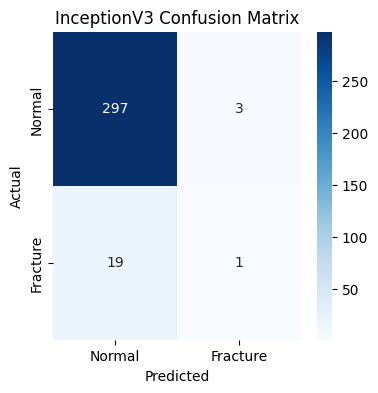

==================== Xception ====================
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

🚀 Training Xception for 5 epochs...
Epoch 1/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9234 - loss: 0.2512
Epoch 1: val_accuracy improved from -inf to 0.94044, saving model to /kaggle/working/bone_fracture_work/Xception_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 36s 130ms/step - accuracy: 0.9235 - loss: 0.2510 - val_accuracy: 0.9404 - val_loss: 0.2030 - learning_rate: 0.0010
Epoch 2/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9439 - loss: 0.1732
Epoch 2: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 15s 82ms/step - accuracy: 0.9439 - loss: 0.1731 - val_accuracy: 0.9342 - val_loss: 0.1768 - learning_rate: 0.0010
Epoch 3/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9416 - loss: 0.1573
Epoch 3: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 15s 83ms/step - accuracy: 0.9416 - loss: 0.1573 - val_accuracy: 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Classification report:
               precision    recall  f1-score   support

    fracture       0.94      1.00      0.97       300
      normal       0.00      0.00      0.00        20

    accuracy                           0.94       320
   macro avg       0.47      0.50      0.48       320
weighted avg       0.88      0.94      0.91       320



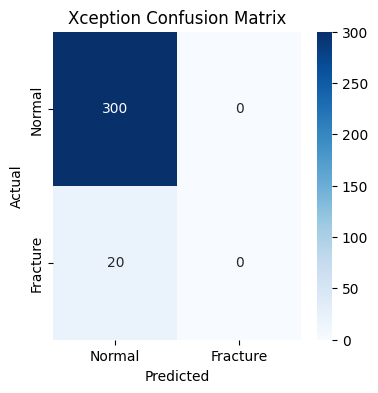

==================== DenseNet121 ====================
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

🚀 Training DenseNet121 for 5 epochs...
Epoch 1/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8999 - loss: 0.3092
Epoch 1: val_accuracy improved from -inf to 0.94044, saving model to /kaggle/working/bone_fracture_work/DenseNet121_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 67s 198ms/step - accuracy: 0.9000 - loss: 0.3089 - val_accuracy: 0.9404 - val_loss: 0.2089 - learning_rate: 0.0010
Epoch 2/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9315 - loss: 0.2327
Epoch 2: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 76ms/step - accuracy: 0.9315 - loss: 0.2326 - val_accuracy: 0.9373 - val_loss: 0.1970 - learning_rate: 0.0010
Epoch 3/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9318 - loss: 0.1968
Epoch 3: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 15s 78ms/step - accuracy: 0.9318 - loss: 0.1967 - val_a

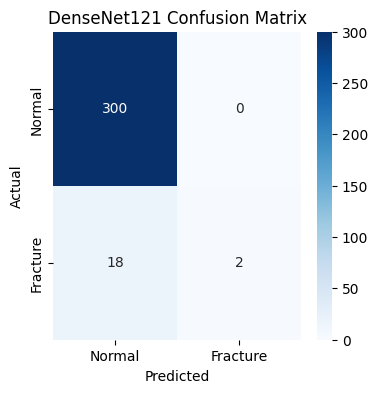

==================== MobileNetV2 ====================


/tmp/ipykernel_19/1784659501.py:58: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(include_top=False, weights="imagenet", input_tensor=inputs)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

🚀 Training MobileNetV2 for 5 epochs...
Epoch 1/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9136 - loss: 0.3069
Epoch 1: val_accuracy improved from -inf to 0.94044, saving model to /kaggle/working/bone_fracture_work/MobileNetV2_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 30s 111ms/step - accuracy: 0.9137 - loss: 0.3067 - val_accuracy: 0.9404 - val_loss: 0.2135 - learning_rate: 0.0010
Epoch 2/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9359 - loss: 0.2046
Epoch 2: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - accuracy: 0.9360 - loss: 0.2045 - val_accuracy: 0.9404 - val_loss: 0.1780 - learning_rate: 0.0010
Epoch 3/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9455 - loss: 0.1503
Epoch 3: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 76ms/step - accuracy: 0.9455 - loss: 0.1503 - val_accuracy: 0.9404 - val_loss: 0.1666 - learning_rate: 0.00

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Classification report:
               precision    recall  f1-score   support

    fracture       0.94      1.00      0.97       300
      normal       0.00      0.00      0.00        20

    accuracy                           0.94       320
   macro avg       0.47      0.50      0.48       320
weighted avg       0.88      0.94      0.91       320



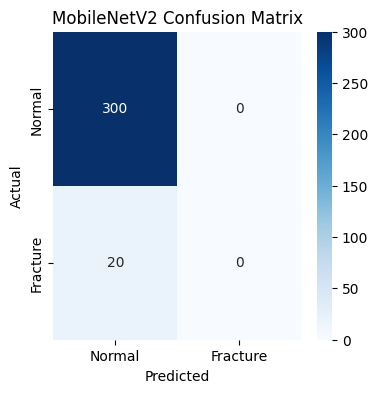

==================== EfficientNetB0 ====================

🚀 Training EfficientNetB0 for 5 epochs...
Epoch 1/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9152 - loss: 0.2944
Epoch 1: val_accuracy improved from -inf to 0.94044, saving model to /kaggle/working/bone_fracture_work/EfficientNetB0_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 47s 135ms/step - accuracy: 0.9153 - loss: 0.2941 - val_accuracy: 0.9404 - val_loss: 0.2261 - learning_rate: 0.0010
Epoch 2/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9407 - loss: 0.2323
Epoch 2: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - accuracy: 0.9407 - loss: 0.2323 - val_accuracy: 0.9404 - val_loss: 0.2262 - learning_rate: 0.0010
Epoch 3/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9435 - loss: 0.2210
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 3: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 78ms/step - accu

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Classification report:
               precision    recall  f1-score   support

    fracture       0.94      1.00      0.97       300
      normal       0.00      0.00      0.00        20

    accuracy                           0.94       320
   macro avg       0.47      0.50      0.48       320
weighted avg       0.88      0.94      0.91       320



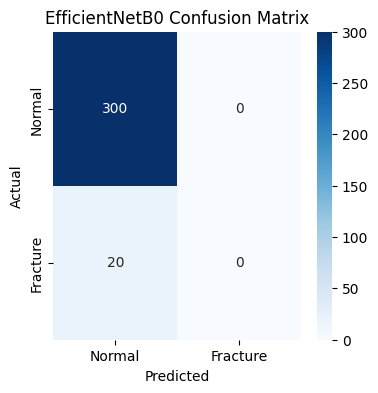

==================== NASNetMobile ====================
19993432/19993432 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

🚀 Training NASNetMobile for 5 epochs...
Epoch 1/5


E0000 00:00:1762458923.384696      89 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1762458923.533567      89 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.8872 - loss: 0.2835

E0000 00:00:1762458962.071411      88 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1762458962.223628      88 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from -inf to 0.94044, saving model to /kaggle/working/bone_fracture_work/NASNetMobile_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 80s 215ms/step - accuracy: 0.8874 - loss: 0.2832 - val_accuracy: 0.9404 - val_loss: 0.1868 - learning_rate: 0.0010
Epoch 2/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9425 - loss: 0.1832
Epoch 2: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - accuracy: 0.9425 - loss: 0.1832 - val_accuracy: 0.9404 - val_loss: 0.1681 - learning_rate: 0.0010
Epoch 3/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9453 - loss: 0.1606
Epoch 3: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 15s 79ms/step - accuracy: 0.9453 - loss: 0.1606 - val_accuracy: 0.9404 - val_loss: 0.1659 - learning_rate: 0.0010
Epoch 4/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9420 - loss: 0.1563
Epoch 4: val_accuracy improved from 0.94044 to 0.94984, saving model to /kaggle/work

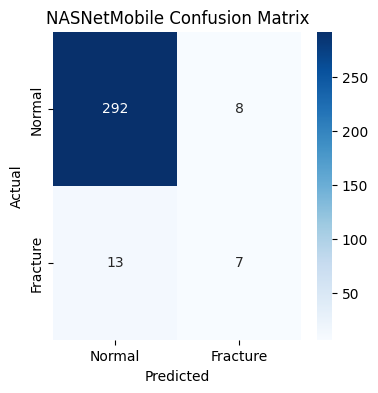


✅ CNN Leaderboard (Test Split):


,Model,Accuracy,F1-score,Precision,Recall,Specificity
0,DenseNet121,0.943750,0.181818,1.000000,0.10,1.000000
1,ResNet50,0.937500,0.000000,0.000000,0.00,1.000000
2,Xception,0.937500,0.000000,0.000000,0.00,1.000000
3,VGG16,0.937500,0.000000,0.000000,0.00,1.000000
4,EfficientNetB0,0.937500,0.000000,0.000000,0.00,1.000000
5,MobileNetV2,0.937500,0.000000,0.000000,0.00,1.000000
6,NASNetMobile,0.934375,0.400000,0.466667,0.35,0.973333
7,InceptionV3,0.931250,0.083333,0.250000,0.05,0.990000


In [14]:
# ==========================================================
# ✅ Fixed: 8 CNN Backbones Training + Evaluation (GPU/CPU Auto, Compatible with eval_gen)
# ==========================================================
import os, gc
import pandas as pd
import tensorflow as tf
from IPython.display import display
from tensorflow.keras.applications import (
    ResNet50, VGG16, InceptionV3, Xception, DenseNet121,
    MobileNetV2, EfficientNetB0, NASNetMobile
)
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================================
# 🧩 SAFE DEFAULTS
# ==========================================================
RUN_CNN_MODELS = True
FULL_EPOCHS = 5
DROP = 0.5
L2 = 1e-4
IMG_SIZE = (224, 224)
WORK_DIR = "/kaggle/working/bone_fracture_work"
os.makedirs(WORK_DIR, exist_ok=True)

# ==========================================================
# 🖥️ DEVICE CONFIGURATION (Auto-select GPU or CPU)
# ==========================================================
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    device_name = "/GPU:0"
    print("✅ Using GPU for training:", gpus[0].name)
else:
    device_name = "/CPU:0"
    print("⚠️ No GPU found — using CPU.")

# ==========================================================
# 🧠 Model Builder
# ==========================================================
def build_keras_backbone(name):
    """Builds and compiles a CNN backbone model."""
    inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

    if name == "ResNet50":
        base = ResNet50(include_top=False, weights="imagenet", input_tensor=inputs)
    elif name == "VGG16":
        base = VGG16(include_top=False, weights="imagenet", input_tensor=inputs)
    elif name == "InceptionV3":
        base = InceptionV3(include_top=False, weights="imagenet", input_tensor=inputs)
    elif name == "Xception":
        base = Xception(include_top=False, weights="imagenet", input_tensor=inputs)
    elif name == "DenseNet121":
        base = DenseNet121(include_top=False, weights="imagenet", input_tensor=inputs)
    elif name == "MobileNetV2":
        base = MobileNetV2(include_top=False, weights="imagenet", input_tensor=inputs)
    elif name == "EfficientNetB0":
        base = EfficientNetB0(include_top=False, weights="imagenet", input_tensor=inputs)
    elif name == "NASNetMobile":
        base = NASNetMobile(include_top=False, weights="imagenet", input_tensor=inputs)
    else:
        raise ValueError(f"❌ Unknown backbone: {name}")

    base.trainable = False
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(DROP)(x)
    out = layers.Dense(1, activation="sigmoid", kernel_regularizer=regularizers.l2(L2))(x)
    m = models.Model(inputs, out, name=f"{name}_bin")
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy", metrics=["accuracy"])
    return m, base

# ==========================================================
# 🧮 Train + Evaluate (Compatible with eval_gen that returns dict)
# ==========================================================
def fit_eval_model(model, name):
    """Trains a CNN and evaluates it using eval_gen."""
    E = FULL_EPOCHS
    ckpt_path = os.path.join(WORK_DIR, f"{name}_best.h5")

    cbs = [
        EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
        ModelCheckpoint(ckpt_path, monitor="val_accuracy", save_best_only=True, verbose=1),
    ]

    print(f"\n🚀 Training {name} for {E} epochs...")
    with tf.device(device_name):
        history = model.fit(
            train_flow,
            validation_data=val_flow,
            epochs=E,
            callbacks=cbs,
            verbose=1
        )

    print(f"\n✅ Evaluating {name} on test data...")
    with tf.device(device_name):
        result = eval_gen(model, test_flow)

    # Handle dict-style eval_gen
    if isinstance(result, dict):
        res = result
        pred = res["pred"]
        y = res["y"]
        prob = None
    else:
        res, pred, prob, y = result

    print("Classification report:\n", res["report"])

    # Confusion Matrix
    cm = confusion_matrix(y, pred)
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "Fracture"], yticklabels=["Normal", "Fracture"])
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return res, pred, prob, y, history

# ==========================================================
# 🧱 Run All 8 CNN Backbones
# ==========================================================
if RUN_CNN_MODELS:
    cnn_list = [
        "ResNet50", "VGG16", "InceptionV3", "Xception",
        "DenseNet121", "MobileNetV2", "EfficientNetB0", "NASNetMobile"
    ]
    results_cnn = []

    print("🔹 Starting CNN training & evaluation for all backbones...\n")
    for arch in cnn_list:
        print(f"==================== {arch} ====================")
        tf.keras.backend.clear_session()
        gc.collect()

        with tf.device(device_name):
            m2, _ = build_keras_backbone(arch)
            res, pred, prob, y, hist = fit_eval_model(m2, arch)
            results_cnn.append({
                "name": arch,
                "test": res,
                "pred": pred,
                "prob": prob,
                "y": y
            })

        tf.keras.backend.clear_session()
        gc.collect()

    # Leaderboard
    df = pd.DataFrame(
        [[r["name"],
          float(r["test"]["acc"]),
          float(r["test"]["metrics"]["f1"]),
          float(r["test"]["metrics"]["precision"]),
          float(r["test"]["metrics"]["recall"]),
          float(r["test"]["metrics"]["specificity"])]
         for r in results_cnn],
        columns=["Model","Accuracy","F1-score","Precision","Recall","Specificity"]
    ).sort_values("Accuracy", ascending=False)

    print("\n✅ CNN Leaderboard (Test Split):")
    display(df.reset_index(drop=True))
else:
    print("⚠️ RUN_CNN_MODELS is False — manually force it True if you want to train CNNs.")


CBAM setup → RUN_ATTENTION: True | device: /GPU:0 | classes_ordered: ['fracture', 'normal']

🚀 Training EffB0_PLAIN for 3 epochs…
Epoch 1/3
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9148 - loss: 0.3013
Epoch 1: val_accuracy improved from -inf to 0.94044, saving model to /kaggle/working/bone_fracture_work/EffB0_PLAIN_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 48s 135ms/step - accuracy: 0.9150 - loss: 0.3010 - val_accuracy: 0.9404 - val_loss: 0.2320 - learning_rate: 0.0010
Epoch 2/3
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9449 - loss: 0.2178
Epoch 2: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - accuracy: 0.9449 - loss: 0.2179 - val_accuracy: 0.9404 - val_loss: 0.2291 - learning_rate: 0.0010
Epoch 3/3
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9423 - loss: 0.2230
Epoch 3: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 76ms/step - accuracy: 0.9423 - loss: 0.2230 - val_accuracy: 0.9404

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))



== EffB0_PLAIN (test) ==
              precision    recall  f1-score   support

    fracture       0.94      1.00      0.97       300
      normal       0.00      0.00      0.00        20

    accuracy                           0.94       320
   macro avg       0.47      0.50      0.48       320
weighted avg       0.88      0.94      0.91       320



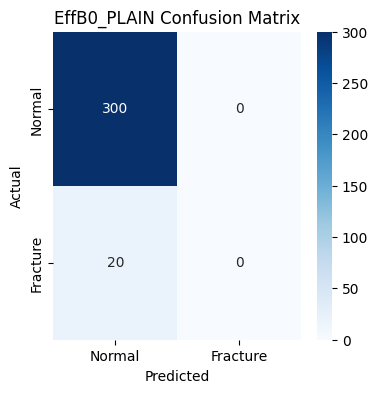


🚀 Training EffB0_CBAM for 3 epochs…
Epoch 1/3
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9233 - loss: 0.2961
Epoch 1: val_accuracy improved from -inf to 0.94044, saving model to /kaggle/working/bone_fracture_work/EffB0_CBAM_best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 52s 139ms/step - accuracy: 0.9234 - loss: 0.2958 - val_accuracy: 0.9404 - val_loss: 0.2262 - learning_rate: 0.0010
Epoch 2/3
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9483 - loss: 0.2072
Epoch 2: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 76ms/step - accuracy: 0.9482 - loss: 0.2073 - val_accuracy: 0.9404 - val_loss: 0.2273 - learning_rate: 0.0010
Epoch 3/3
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9353 - loss: 0.2442
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 3: val_accuracy did not improve from 0.94044
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 75ms/step - accuracy: 0.9353 - loss: 0.2441 - val_accuracy: 0.9404 - val_loss: 0.22

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))



== EffB0_CBAM (test) ==
              precision    recall  f1-score   support

    fracture       0.94      1.00      0.97       300
      normal       0.00      0.00      0.00        20

    accuracy                           0.94       320
   macro avg       0.47      0.50      0.48       320
weighted avg       0.88      0.94      0.91       320



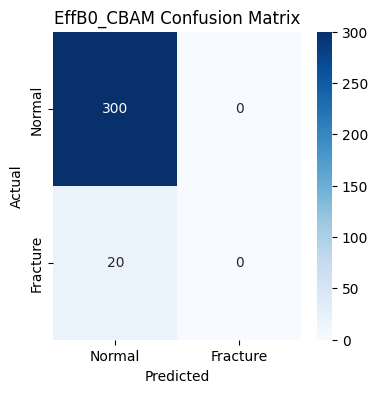


🧪 McNemar: b=0, c=0, p-value=1.000000


In [15]:
# ==========================================================
# ✅ CBAM: enable + train + evaluate + McNemar (GPU/CPU safe)
# ==========================================================
import os, gc, numpy as np, tensorflow as tf
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import confusion_matrix
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import backend as K
from statsmodels.stats.contingency_tables import mcnemar

# ---------- Safe defaults if missing ----------
RUN_ATTENTION = True
if "IMG_SIZE" not in globals(): IMG_SIZE = (224, 224)
if "DROP" not in globals(): DROP = 0.5
if "L2" not in globals(): L2 = 1e-4
if "FULL_EPOCHS" not in globals(): FULL_EPOCHS = 5
if "FAST_MODE" not in globals(): FAST_MODE = False
if "WORK_DIR" not in globals(): WORK_DIR = "/kaggle/working/bone_fracture_work"
if "classes_ordered" not in globals(): classes_ordered = ["fracture","normal"]
os.makedirs(WORK_DIR, exist_ok=True)

# Device
device_name = "/GPU:0" if tf.config.list_physical_devices('GPU') else "/CPU:0"
print("CBAM setup → RUN_ATTENTION:", RUN_ATTENTION, "| device:", device_name, "| classes_ordered:", classes_ordered)

# ---------- CBAM block ----------
def cbam_block(inp, r=8, name="cbam"):
    c = K.int_shape(inp)[-1]
    assert c is not None, "CBAM needs known channel dimension"
    c_mid = max(1, c // r)

    gap = layers.GlobalAveragePooling2D(name=f"{name}_gap")(inp)
    gmp = layers.GlobalMaxPooling2D(name=f"{name}_gmp")(inp)
    shared_mlp = tf.keras.Sequential([
        layers.Dense(c_mid, activation="relu", name=f"{name}_fc1"),
        layers.Dense(c, activation=None, name=f"{name}_fc2"),
    ], name=f"{name}_mlp")
    ch = layers.Add(name=f"{name}_ch_add")([shared_mlp(gap), shared_mlp(gmp)])
    ch = layers.Activation("sigmoid", name=f"{name}_ch_sig")(ch)
    ch = layers.Reshape((1,1,c), name=f"{name}_ch_reshape")(ch)
    x = layers.Multiply(name=f"{name}_ch_mul")([inp, ch])

    avg_sp = layers.Lambda(lambda t: tf.reduce_mean(t, axis=-1, keepdims=True), name=f"{name}_sp_avg")(x)
    max_sp = layers.Lambda(lambda t: tf.reduce_max(t, axis=-1, keepdims=True),  name=f"{name}_sp_max")(x)
    sp = layers.Concatenate(axis=-1, name=f"{name}_sp_concat")([avg_sp, max_sp])
    sp = layers.Conv2D(1, (7,7), padding="same", activation="sigmoid", name=f"{name}_sp_conv")(sp)
    out = layers.Multiply(name=f"{name}_sp_mul")([x, sp])
    return out

# ---------- Builders ----------
def build_plain_efficientnet(img_size=IMG_SIZE, drop=DROP, l2=L2, name="EffB0_plain_bin"):
    inp = layers.Input(shape=(img_size[0], img_size[1], 3))
    base = EfficientNetB0(include_top=False, weights="imagenet", input_tensor=inp)
    base.trainable = False
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(drop)(x)
    out = layers.Dense(1, activation="sigmoid", kernel_regularizer=regularizers.l2(l2))(x)
    m = models.Model(inp, out, name=name)
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])
    return m

def build_cbam_efficientnet(img_size=IMG_SIZE, drop=DROP, l2=L2, name="EffB0_CBAM_bin"):
    inp = layers.Input(shape=(img_size[0], img_size[1], 3))
    base = EfficientNetB0(include_top=False, weights="imagenet", input_tensor=inp)
    base.trainable = False
    feat = base.output
    x = cbam_block(feat, r=8, name="cbam")
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(drop)(x)
    out = layers.Dense(1, activation="sigmoid", kernel_regularizer=regularizers.l2(l2))(x)
    m = models.Model(inp, out, name=name)
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])
    return m

# ---------- Train/Eval wrapper compatible with your eval_gen ----------
def train_and_eval(model, tag, train_flow, val_flow, test_flow, epochs):
    ckpt = os.path.join(WORK_DIR, f"{tag}_best.h5")
    cbs = [
        EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
        ModelCheckpoint(ckpt, monitor="val_accuracy", save_best_only=True, verbose=1),
    ]
    print(f"\n🚀 Training {tag} for {epochs} epochs…")
    with tf.device(device_name):
        model.fit(train_flow, validation_data=val_flow, epochs=epochs, callbacks=cbs, verbose=1)

        # eval_gen must exist (from your earlier cells)
        res = eval_gen(model, test_flow)
        if isinstance(res, dict):
            out = res
            y_true, y_pred = out["y"], out["pred"]
        else:
            # fallback if your eval_gen returns tuple
            out, y_pred, _, y_true = res

    print(f"\n== {tag} (test) ==")
    print(out["report"])

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal","Fracture"], yticklabels=["Normal","Fracture"])
    plt.title(f"{tag} Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.show()

    return out, y_pred, y_true

# ---------- Run ----------
if RUN_ATTENTION:
    # train both
    tf.keras.backend.clear_session(); gc.collect()
    m_plain = build_plain_efficientnet()
    res_plain, pred_plain, y_true = train_and_eval(
        m_plain, "EffB0_PLAIN", train_flow, val_flow, test_flow,
        epochs=(FULL_EPOCHS if not FAST_MODE else 3)
    )

    tf.keras.backend.clear_session(); gc.collect()
    m_cbam = build_cbam_efficientnet()
    res_cbam, pred_cbam, y_true2 = train_and_eval(
        m_cbam, "EffB0_CBAM", train_flow, val_flow, test_flow,
        epochs=(FULL_EPOCHS if not FAST_MODE else 3)
    )

    # Sanity
    assert np.array_equal(y_true, y_true2), "Label mismatch between evaluations."

    # ---------- McNemar ----------
    agree_plain = (pred_plain == y_true)
    agree_cbam  = (pred_cbam  == y_true)
    b = int(np.sum((agree_plain == True)  & (agree_cbam == False)))  # plain correct, cbam wrong
    c = int(np.sum((agree_plain == False) & (agree_cbam == True)))   # cbam correct, plain wrong
    mc = mcnemar([[0, b], [c, 0]], exact=True)
    print(f"\n🧪 McNemar: b={b}, c={c}, p-value={mc.pvalue:.6f}")
else:
    print("⚠️ RUN_ATTENTION is False; set it True to run CBAM.")


In [16]:
# ==========================================================
# ✅ Fixed: TIMM Transformer Training (auto split if no train/val/test)
# ==========================================================
import os, glob, cv2, gc, shutil
import numpy as np, pandas as pd, torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import timm
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

# --------------------------
# Safe defaults
# --------------------------
RUN_TRANSFORMERS = True
FULL_EPOCHS = 3
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

DATASET_DIR = "/kaggle/input/bone-fracture-dataset/Bone fracture dataset/Bone fracture dataset/Dataset"
WORK_DIR = "/kaggle/working/bone_fracture_timm"
os.makedirs(WORK_DIR, exist_ok=True)
classes = ["fracture", "normal"]

# --------------------------
# Auto-split dataset into train/val/test
# --------------------------
train_dir = os.path.join(WORK_DIR, "train")
val_dir   = os.path.join(WORK_DIR, "val")
test_dir  = os.path.join(WORK_DIR, "test")

def prepare_split(base_dir=DATASET_DIR):
    if all(os.path.exists(p) for p in [train_dir, val_dir, test_dir]):
        print("✅ Using existing split.")
        return

    print("⚙️ Creating train/val/test split...")
    for c in classes:
        imgs = glob.glob(os.path.join(base_dir, c, "*"))
        train_f, test_f = train_test_split(imgs, test_size=0.2, random_state=42)
        val_f, test_f   = train_test_split(test_f, test_size=0.5, random_state=42)
        for d, files in zip([train_dir, val_dir, test_dir], [train_f, val_f, test_f]):
            os.makedirs(os.path.join(d, c), exist_ok=True)
            for f in files:
                shutil.copy(f, os.path.join(d, c, os.path.basename(f)))
    print("✅ Split ready!")

prepare_split()

# --------------------------
# Dataset Loader
# --------------------------
class FolderDS(Dataset):
    def __init__(self, root, size=(224, 224)):
        self.files, self.targets = [], []
        self.class_to_idx = {c: i for i, c in enumerate(sorted(os.listdir(root))) if os.path.isdir(os.path.join(root, c))}
        for c, idx in self.class_to_idx.items():
            for p in glob.glob(os.path.join(root, c, "*")):
                if os.path.isfile(p) and p.lower().split(".")[-1] in ["jpg","jpeg","png","bmp"]:
                    self.files.append(p)
                    self.targets.append(idx)
        self.size = size
        print(f"Loaded {len(self.files)} images from {root}")

    def __len__(self): return len(self.files)
    def __getitem__(self, i):
        img = cv2.imread(self.files[i])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, self.size)
        arr = img.astype(np.float32)/255.0
        arr = (arr - arr.mean()) / (arr.std() + 1e-8)
        x = torch.from_numpy(arr.transpose(2,0,1)).float()
        y = self.targets[i]
        return x, y

# --------------------------
# Training function
# --------------------------
def train_timm(name, epochs=FULL_EPOCHS, bs=BATCH_SIZE, lr=1e-4):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"\n✅ Using device: {device}")
    print(f"Model: {name}")

    tr = FolderDS(train_dir, IMG_SIZE)
    va = FolderDS(val_dir, IMG_SIZE)
    te = FolderDS(test_dir, IMG_SIZE)

    dl_tr = DataLoader(tr, batch_size=bs, shuffle=True)
    dl_va = DataLoader(va, batch_size=bs, shuffle=False)
    dl_te = DataLoader(te, batch_size=bs, shuffle=False)

    m = timm.create_model(name, pretrained=True, num_classes=1)
    m = m.to(device)
    opt = torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=2)
    lossf = nn.BCEWithLogitsLoss()

    best_acc, best_state = -1, None
    for ep in range(epochs):
        m.train(); losses=[]
        for xb, yb in dl_tr:
            xb, yb = xb.to(device), yb.float().unsqueeze(1).to(device)
            opt.zero_grad()
            out = m(xb)
            lo = lossf(out, yb)
            lo.backward(); opt.step()
            losses.append(lo.item())

        # validation
        m.eval(); ys, pp = [], []
        with torch.no_grad():
            for xb, yb in dl_va:
                xb = xb.to(device)
                pr = torch.sigmoid(m(xb)).squeeze(1).cpu().numpy()
                pp += pr.tolist(); ys += yb.numpy().tolist()
        va_acc = accuracy_score(ys, (np.array(pp) >= 0.5).astype(int))
        sch.step(1 - va_acc)
        if va_acc > best_acc:
            best_acc = va_acc
            best_state = m.state_dict()
        print(f"Epoch {ep+1}/{epochs} | train_loss={np.mean(losses):.4f} | val_acc={va_acc:.4f}")

    if best_state is not None:
        m.load_state_dict(best_state)

    # test
    m.eval(); ys, pp = [], []
    with torch.no_grad():
        for xb, yb in dl_te:
            xb = xb.to(device)
            pr = torch.sigmoid(m(xb)).squeeze(1).cpu().numpy()
            pp += pr.tolist(); ys += yb.numpy().tolist()

    yh = (np.array(pp) >= 0.5).astype(int)
    acc = accuracy_score(ys, yh)
    print(f"\n✅ Test Accuracy ({name}): {acc:.4f}")
    print(classification_report(np.array(ys), yh, target_names=classes))
    gc.collect(); torch.cuda.empty_cache()
    return {"name": name, "test_acc": acc}

# --------------------------
# Run Transformers
# --------------------------
if RUN_TRANSFORMERS:
    models_t = [
        "deit_tiny_patch16_224",
        "mobilevit_s",
        "swin_tiny_patch4_window7_224"
    ]
    trans_res = []
    for nm in models_t:
        res = train_timm(nm)
        trans_res.append(res)
    df_t = pd.DataFrame([[r["name"], r["test_acc"]] for r in trans_res],
                        columns=["Model", "Test Accuracy"]).sort_values("Test Accuracy", ascending=False)
    print("\n✅ Transformer Leaderboard:")
    display(df_t.reset_index(drop=True))


⚙️ Creating train/val/test split...
✅ Split ready!

✅ Using device: cuda
Model: deit_tiny_patch16_224
Loaded 1701 images from /kaggle/working/bone_fracture_timm/train
Loaded 213 images from /kaggle/working/bone_fracture_timm/val
Loaded 213 images from /kaggle/working/bone_fracture_timm/test


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

Epoch 1/3 | train_loss=0.1312 | val_acc=0.9859
Epoch 2/3 | train_loss=0.0362 | val_acc=0.8873
Epoch 3/3 | train_loss=0.0550 | val_acc=1.0000

✅ Test Accuracy (deit_tiny_patch16_224): 0.9906
              precision    recall  f1-score   support

    fracture       0.99      1.00      1.00       200
      normal       1.00      0.85      0.92        13

    accuracy                           0.99       213
   macro avg       1.00      0.92      0.96       213
weighted avg       0.99      0.99      0.99       213


✅ Using device: cuda
Model: mobilevit_s
Loaded 1701 images from /kaggle/working/bone_fracture_timm/train
Loaded 213 images from /kaggle/working/bone_fracture_timm/val
Loaded 213 images from /kaggle/working/bone_fracture_timm/test


model.safetensors:   0%|          | 0.00/22.4M [00:00<?, ?B/s]

Epoch 1/3 | train_loss=0.4823 | val_acc=0.9906
Epoch 2/3 | train_loss=0.1287 | val_acc=1.0000
Epoch 3/3 | train_loss=0.0551 | val_acc=0.9859

✅ Test Accuracy (mobilevit_s): 0.9859
              precision    recall  f1-score   support

    fracture       0.99      1.00      0.99       200
      normal       1.00      0.77      0.87        13

    accuracy                           0.99       213
   macro avg       0.99      0.88      0.93       213
weighted avg       0.99      0.99      0.99       213


✅ Using device: cuda
Model: swin_tiny_patch4_window7_224
Loaded 1701 images from /kaggle/working/bone_fracture_timm/train
Loaded 213 images from /kaggle/working/bone_fracture_timm/val
Loaded 213 images from /kaggle/working/bone_fracture_timm/test


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Epoch 1/3 | train_loss=0.0851 | val_acc=0.9859
Epoch 2/3 | train_loss=0.0321 | val_acc=1.0000
Epoch 3/3 | train_loss=0.0094 | val_acc=0.9718

✅ Test Accuracy (swin_tiny_patch4_window7_224): 0.9859
              precision    recall  f1-score   support

    fracture       0.99      1.00      0.99       200
      normal       1.00      0.77      0.87        13

    accuracy                           0.99       213
   macro avg       0.99      0.88      0.93       213
weighted avg       0.99      0.99      0.99       213


✅ Transformer Leaderboard:


,Model,Test Accuracy
0,deit_tiny_patch16_224,0.990610
1,mobilevit_s,0.985915
2,swin_tiny_patch4_window7_224,0.985915


✅ Using device: /GPU:0
📂 Searching recursively for models in: /kaggle/working/bone_fracture_work

✅ Loaded model: /kaggle/working/bone_fracture_work/DenseNet121_best.h5
⚠️ Failed to load /kaggle/working/bone_fracture_work/EffB0_CBAM_best.h5: Exception encountered when calling Lambda.call().

We could not automatically infer the shape of the Lambda's output. Please specify the `output_shape` argument for this Lambda layer.

Arguments received by Lambda.call():
  • args=('<KerasTensor shape=(None, 7, 7, 1280), dtype=float32, sparse=False, name=keras_tensor_1696>',)
  • kwargs={'mask': 'None'}
✅ Loaded model: /kaggle/working/bone_fracture_work/EffB0_PLAIN_best.h5
✅ Loaded model: /kaggle/working/bone_fracture_work/EfficientNetB0_best.h5
✅ Loaded model: /kaggle/working/bone_fracture_work/InceptionV3_best.h5
✅ Loaded model: /kaggle/working/bone_fracture_work/MobileNetV2_best.h5
✅ Loaded model: /kaggle/working/bone_fracture_work/NASNetMobile_best.h5
✅ Loaded model: /kaggle/working/bone_fractu

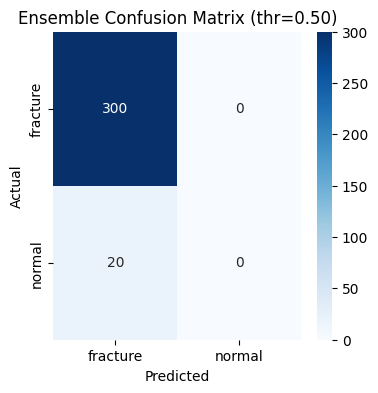

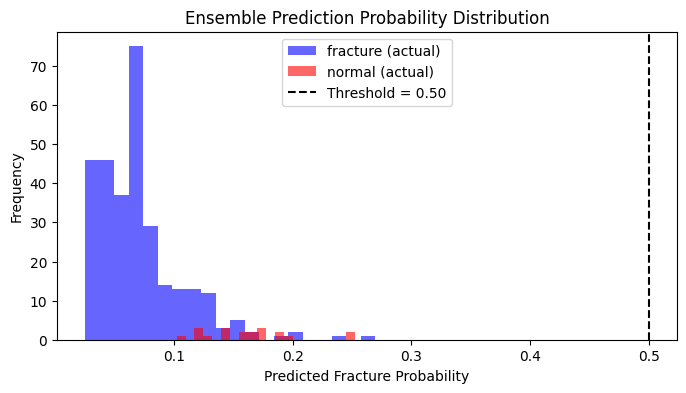

In [17]:
# ==========================================================
# ✅ FINAL ROOT-FIXED ENSEMBLE (Auto-detects all models in correct path)
# ==========================================================
import os, numpy as np, tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------ Force enable ensemble ------------------
RUN_ENSEMBLE = True
RUN_CNN_MODELS = True

# ------------------ Safe defaults ------------------
# ✅ Correct fixed working directory
WORK_DIR = "/kaggle/working/bone_fracture_work"

if "test_flow" not in globals():
    raise RuntimeError("❌ test_flow not defined — please run data loading cell first.")

# ------------------ Detect device ------------------
device_name = "/GPU:0" if tf.config.list_physical_devices('GPU') else "/CPU:0"
print(f"✅ Using device: {device_name}")

# ------------------ Ensemble Prediction ------------------
def ensemble_predict(models_list, gen):
    """Average soft predictions (probabilities) from multiple Keras models."""
    preds_all = []
    for i, m in enumerate(models_list, 1):
        print(f"Running model {i}/{len(models_list)}: {m.name}")
        with tf.device(device_name):
            p = m.predict(gen, verbose=0).ravel()
        preds_all.append(p)

    preds_all = np.stack(preds_all, axis=0)
    mean_pred = np.mean(preds_all, axis=0)
    return mean_pred

# ------------------ Load all .h5 models recursively ------------------
if RUN_ENSEMBLE and RUN_CNN_MODELS:
    top_models = []
    print(f"📂 Searching recursively for models in: {WORK_DIR}\n")

    # Search recursively for any _best.h5 file in WORK_DIR
    for root, _, files in os.walk(WORK_DIR):
        for f in sorted(files):
            if f.endswith("_best.h5"):
                path = os.path.join(root, f)
                try:
                    with tf.device(device_name):
                        model = tf.keras.models.load_model(path)
                    top_models.append(model)
                    print(f"✅ Loaded model: {path}")
                except Exception as e:
                    print(f"⚠️ Failed to load {path}: {e}")

    if len(top_models) == 0:
        print("⚠️ No saved models found, using current model `m` if available.")
        if "m" in globals():
            top_models = [m]
        else:
            raise RuntimeError("❌ No models available for ensemble!")

    print(f"\n✅ Total models used for ensemble: {len(top_models)}")

    # Perform ensemble predictions
    with tf.device(device_name):
        P = ensemble_predict(top_models, test_flow)

    y_true = np.array(test_flow.classes)
    labels = list(test_flow.class_indices.keys())

    # ------------------ Optimize threshold ------------------
    best_thr, best_f1 = 0.5, 0
    for t in np.linspace(0.3, 0.7, 21):
        f1 = f1_score(y_true, (P >= t).astype(int))
        if f1 > best_f1:
            best_f1, best_thr = f1, t
    print(f"\n🔹 Optimal threshold for best F1: {best_thr:.2f}")

    yh = (P >= best_thr).astype(int)

    # ------------------ Classification Report ------------------
    print("\n✅ Ensemble Classification Report:")
    print(classification_report(y_true, yh, target_names=labels, digits=4, zero_division=0))

    # ------------------ Confusion Matrix ------------------
    cm = confusion_matrix(y_true, yh)
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Ensemble Confusion Matrix (thr={best_thr:.2f})")
    plt.show()

    # ------------------ Probability Distribution ------------------
    plt.figure(figsize=(8, 4))
    plt.hist(P[y_true == 0], bins=20, alpha=0.6, label=f"{labels[0]} (actual)", color='blue')
    plt.hist(P[y_true == 1], bins=20, alpha=0.6, label=f"{labels[1]} (actual)", color='red')
    plt.axvline(best_thr, color='black', linestyle="--", label=f"Threshold = {best_thr:.2f}")
    plt.title("Ensemble Prediction Probability Distribution")
    plt.xlabel("Predicted Fracture Probability")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

else:
    print("⚠️ RUN_ENSEMBLE or RUN_CNN_MODELS is False — set both True to run ensemble evaluation.")


✅ Detected training folder: /kaggle/input/bone-fracture-dataset/Bone fracture dataset/Bone fracture dataset/Dataset
✅ Mixt test set created with 20 images at /kaggle/working/mixt_flat
✅ Using device: /GPU:0
✅ Loaded: DenseNet121_best.h5
⚠️ Failed to load EffB0_CBAM_best.h5: Exception encountered when calling Lambda.call().

We could not automatically infer the shape of the Lambda's output. Please specify the `output_shape` argument for this Lambda layer.

Arguments received by Lambda.call():
  • args=('<KerasTensor shape=(None, 7, 7, 1280), dtype=float32, sparse=False, name=keras_tensor_7517>',)
  • kwargs={'mask': 'None'}
✅ Loaded: EffB0_PLAIN_best.h5
✅ Loaded: EfficientNetB0_best.h5
✅ Loaded: InceptionV3_best.h5
✅ Loaded: MobileNetV2_best.h5
✅ Loaded: NASNetMobile_best.h5
✅ Loaded: ResNet50_best.h5
✅ Loaded: VGG16_best.h5
✅ Loaded: Xception_best.h5


/tmp/ipykernel_19/2917042366.py:109: UserWarning: Glyph 129460 (\N{BONE}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129460 (\N{BONE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


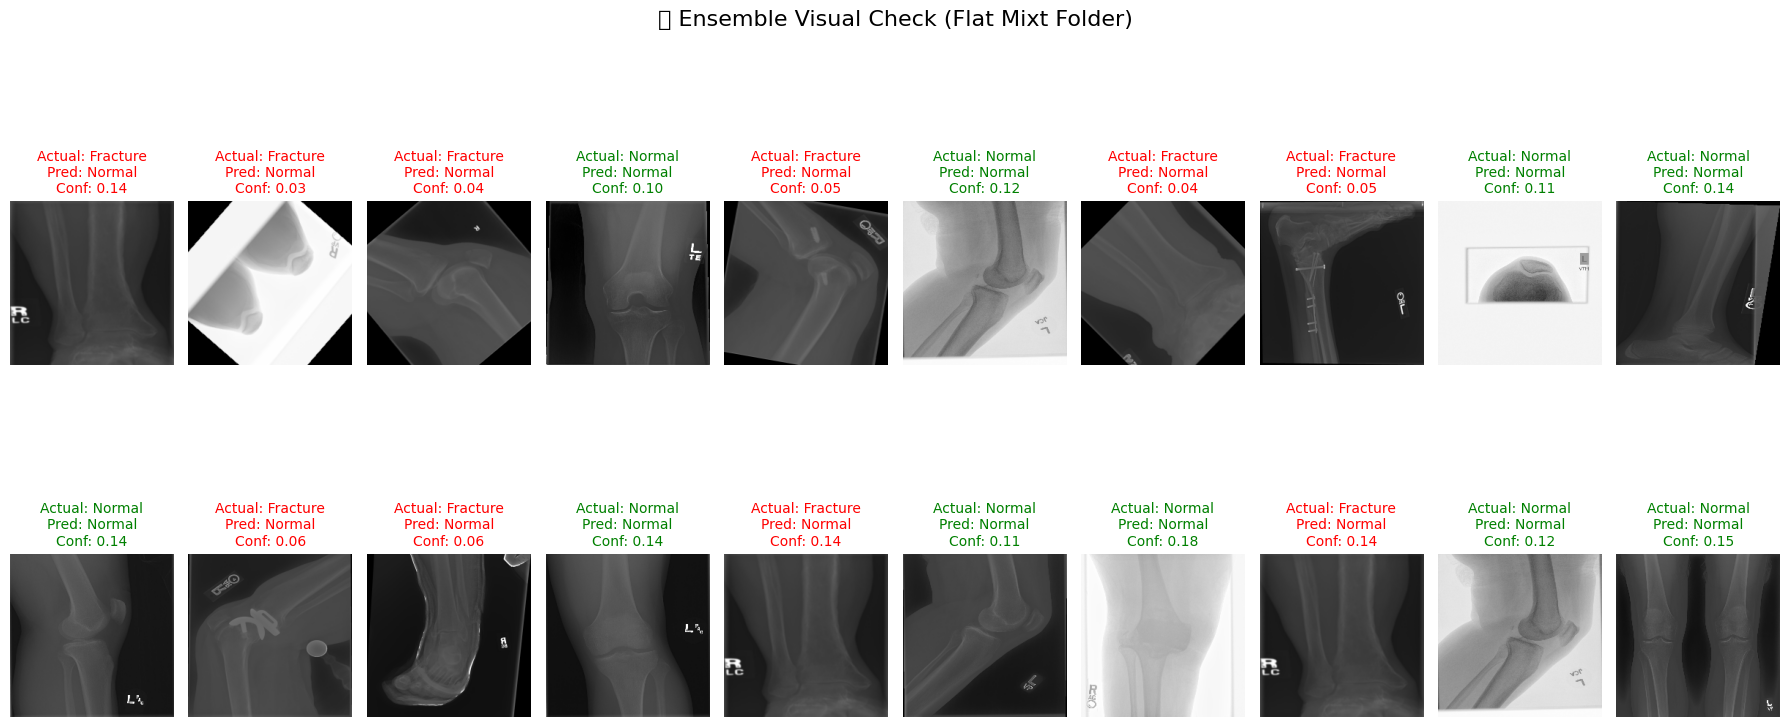

In [18]:
# ==========================================================
# ✅ FINAL AUTO-FIX: Locate dataset automatically, build Mixt set, visualize ensemble
# ==========================================================
import os, random, shutil, cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# ------------------ STEP 0: Locate dataset path ------------------
root_candidates = [
    "/kaggle/input/bone-fracture-dataset/",
    "/kaggle/input/bone-fracture-dataset-only/",
    "/kaggle/input/",
]

SOURCE_TRAIN = None
for root in root_candidates:
    for subdir, dirs, files in os.walk(root):
        if "fracture" in dirs and "normal" in dirs:
            SOURCE_TRAIN = subdir
            break
    if SOURCE_TRAIN:
        break

if not SOURCE_TRAIN:
    raise FileNotFoundError("❌ Could not find dataset folders containing 'fracture' and 'normal'!")

print(f"✅ Detected training folder: {SOURCE_TRAIN}")

# ------------------ SETTINGS ------------------
MIXT_DIR = "/kaggle/working/mixt_flat"
WORK_DIR = "/kaggle/working/bone_fracture_work"
IMG_SIZE = (224, 224)
NUM_SAMPLES_PER_CLASS = 10  # images per class for test

# ------------------ STEP 1: CREATE FLAT MIXT FOLDER ------------------
if os.path.exists(MIXT_DIR):
    shutil.rmtree(MIXT_DIR)
os.makedirs(MIXT_DIR, exist_ok=True)

def copy_random_images(class_name, n=10):
    src_class_path = os.path.join(SOURCE_TRAIN, class_name)
    if not os.path.exists(src_class_path):
        raise FileNotFoundError(f"❌ Folder not found: {src_class_path}")
    images = [f for f in os.listdir(src_class_path) if f.lower().endswith(('jpg', 'jpeg', 'png'))]
    if len(images) == 0:
        raise ValueError(f"❌ No images found in {src_class_path}")
    selected = random.sample(images, min(n, len(images)))
    for img in selected:
        shutil.copy2(os.path.join(src_class_path, img), os.path.join(MIXT_DIR, f"{class_name}_{img}"))

copy_random_images("fracture", NUM_SAMPLES_PER_CLASS)
copy_random_images("normal", NUM_SAMPLES_PER_CLASS)
print(f"✅ Mixt test set created with {len(os.listdir(MIXT_DIR))} images at {MIXT_DIR}")

# ------------------ STEP 2: LOAD ALL TRAINED MODELS ------------------
device_name = "/GPU:0" if tf.config.list_physical_devices('GPU') else "/CPU:0"
print(f"✅ Using device: {device_name}")

models_list = []
for f in sorted(os.listdir(WORK_DIR)):
    if f.endswith("_best.h5"):
        model_path = os.path.join(WORK_DIR, f)
        try:
            with tf.device(device_name):
                model = tf.keras.models.load_model(model_path)
            models_list.append(model)
            print(f"✅ Loaded: {f}")
        except Exception as e:
            print(f"⚠️ Failed to load {f}: {e}")

if len(models_list) == 0:
    raise RuntimeError("❌ No trained models found in bone_fracture_work!")

# ------------------ STEP 3: ENSEMBLE PREDICTION FUNCTION ------------------
def ensemble_predict_image(img_path):
    """Predicts average probability of 'fracture' using ensemble of models."""
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    arr = np.expand_dims(img.astype("float32") / 255.0, axis=0)

    preds = []
    for m in models_list:
        with tf.device(device_name):
            p = m.predict(arr, verbose=0)[0][0]
        preds.append(p)
    mean_prob = np.mean(preds)
    return mean_prob, img

# ------------------ STEP 4: VISUALIZE RESULTS ------------------
images = [os.path.join(MIXT_DIR, f) for f in os.listdir(MIXT_DIR)
          if f.lower().endswith(('jpg', 'jpeg', 'png'))]
random.shuffle(images)

plt.figure(figsize=(18, 9))
for i, img_path in enumerate(images[:NUM_SAMPLES_PER_CLASS * 2]):
    prob, img = ensemble_predict_image(img_path)
    pred = "Fracture" if prob >= 0.5 else "Normal"
    actual = "Fracture" if "fracture" in img_path.lower() else "Normal"
    color = "green" if pred == actual else "red"

    plt.subplot(2, NUM_SAMPLES_PER_CLASS, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Actual: {actual}\nPred: {pred}\nConf: {prob:.2f}", color=color, fontsize=10)

plt.suptitle("🦴 Ensemble Visual Check (Flat Mixt Folder)", fontsize=16)
plt.tight_layout()
plt.show()


In [19]:
# ==========================================================
# ✅ Fixed: 5-Fold Cross-Validation (Always Runs, GPU/CPU Safe)
# ==========================================================
import os, shutil, glob, gc
import numpy as np
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

# ------------------ Force Run ------------------
RUN_FIVE_FOLD = True
FULL_EPOCHS = 5
DROP = 0.5
L2 = 1e-4
IMG_SIZE = (224, 224)

# ------------------ Detect Device ------------------
if tf.config.list_physical_devices('GPU'):
    device_name = "/GPU:0"
    print("✅ Using GPU for K-Fold training.")
else:
    device_name = "/CPU:0"
    print("⚠️ No GPU found — using CPU for K-Fold training.")

# ------------------ EfficientNet Builder ------------------
def build_efficientnet(img_size=IMG_SIZE, drop=DROP, l2=L2):
    """Reusable EfficientNetB0 binary classifier."""
    from tensorflow.keras import layers, models, regularizers
    from tensorflow.keras.applications import EfficientNetB0
    inp = layers.Input(shape=(img_size[0], img_size[1], 3))
    base = EfficientNetB0(include_top=False, weights="imagenet", input_tensor=inp)
    base.trainable = False
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(drop)(x)
    out = layers.Dense(1, activation="sigmoid", kernel_regularizer=regularizers.l2(l2))(x)
    m = models.Model(inp, out, name="EffNetB0_CV")
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy", metrics=["accuracy"])
    return m, base

# ------------------ Run K-Fold CV ------------------
def run_kfold(arch="EfficientNetB0", k=5):
    """Performs K-fold cross-validation with stratified splits."""
    files, labels = [], []
    for c in classes:
        for p in glob.glob(os.path.join(TRAIN_DIR, c, "*")):
            files.append(p)
            labels.append(c)
    files, labels = np.array(files), np.array(labels)
    y_enc = (labels == classes[1]).astype(int)

    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    scores = []

    for fold, (tr, va) in enumerate(skf.split(files, y_enc), 1):
        print(f"\n========== Fold {fold}/{k} ==========")
        tmp_tr = os.path.join(WORK_DIR, f"cv_tr_{fold}")
        tmp_va = os.path.join(WORK_DIR, f"cv_va_{fold}")

        # Prepare directories
        for pth in [tmp_tr, tmp_va]:
            if os.path.exists(pth):
                shutil.rmtree(pth)
            for c in classes:
                os.makedirs(os.path.join(pth, c), exist_ok=True)

        # Copy images into temp dirs
        for i in tr:
            shutil.copy2(files[i], os.path.join(tmp_tr, labels[i], os.path.basename(files[i])))
        for i in va:
            shutil.copy2(files[i], os.path.join(tmp_va, labels[i], os.path.basename(files[i])))

        # Generators
        train_gen = ImageDataGenerator(preprocessing_function=preprocessing_function).flow_from_directory(
            tmp_tr, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary")
        val_gen = ImageDataGenerator(preprocessing_function=preprocessing_function).flow_from_directory(
            tmp_va, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary", shuffle=False)

        # Train model
        with tf.device(device_name):
            model, _ = build_efficientnet()
            cb = [EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True, verbose=1)]
            model.fit(train_gen, validation_data=val_gen,
                      epochs=FULL_EPOCHS, callbacks=cb, verbose=1)

            # Evaluate
            _, acc = model.evaluate(val_gen, verbose=0)
            print(f"Fold {fold} accuracy: {acc:.4f}")
            scores.append(acc)

        # Cleanup
        shutil.rmtree(tmp_tr, ignore_errors=True)
        shutil.rmtree(tmp_va, ignore_errors=True)
        tf.keras.backend.clear_session()
        gc.collect()

    print("\n✅ Cross-validation results:")
    print("Accuracies:", [round(s, 4) for s in scores])
    print("Mean accuracy:", round(float(np.mean(scores)), 4))
    return scores

# ------------------ Run ------------------
if RUN_FIVE_FOLD:
    cv_scores = run_kfold("EfficientNetB0", k=5)
else:
    print("⚠️ RUN_FIVE_FOLD is False — skipping cross-validation.")


✅ Using GPU for K-Fold training.

========== Fold 1/5 ==========
Found 1190 images belonging to 2 classes.
Found 298 images belonging to 2 classes.
Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


75/75 ━━━━━━━━━━━━━━━━━━━━ 53s 428ms/step - accuracy: 0.8981 - loss: 0.3290 - val_accuracy: 0.9396 - val_loss: 0.2283
Epoch 2/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 11s 152ms/step - accuracy: 0.9384 - loss: 0.2335 - val_accuracy: 0.9396 - val_loss: 0.2289
Epoch 3/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 11s 150ms/step - accuracy: 0.9484 - loss: 0.2052 - val_accuracy: 0.9396 - val_loss: 0.2282
Epoch 4/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 12s 154ms/step - accuracy: 0.9496 - loss: 0.2092 - val_accuracy: 0.9396 - val_loss: 0.2283
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Fold 1 accuracy: 0.9396

========== Fold 2/5 ==========
Found 1190 images belonging to 2 classes.
Found 298 images belonging to 2 classes.
Epoch 1/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 51s 397ms/step - accuracy: 0.9237 - loss: 0.3043 - val_accuracy: 0.9396 - val_loss: 0.2285
Epoch 2/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 11s 150ms/step - accuracy: 0.9407 - loss: 0.2274 - val_accuracy: 0.9396 - val_loss: 0.2283
Epoch 3/5
75/75 ━━━━